In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.ndimage import gaussian_filter
from scipy.signal.windows import tukey
from skimage.transform import radon, iradon


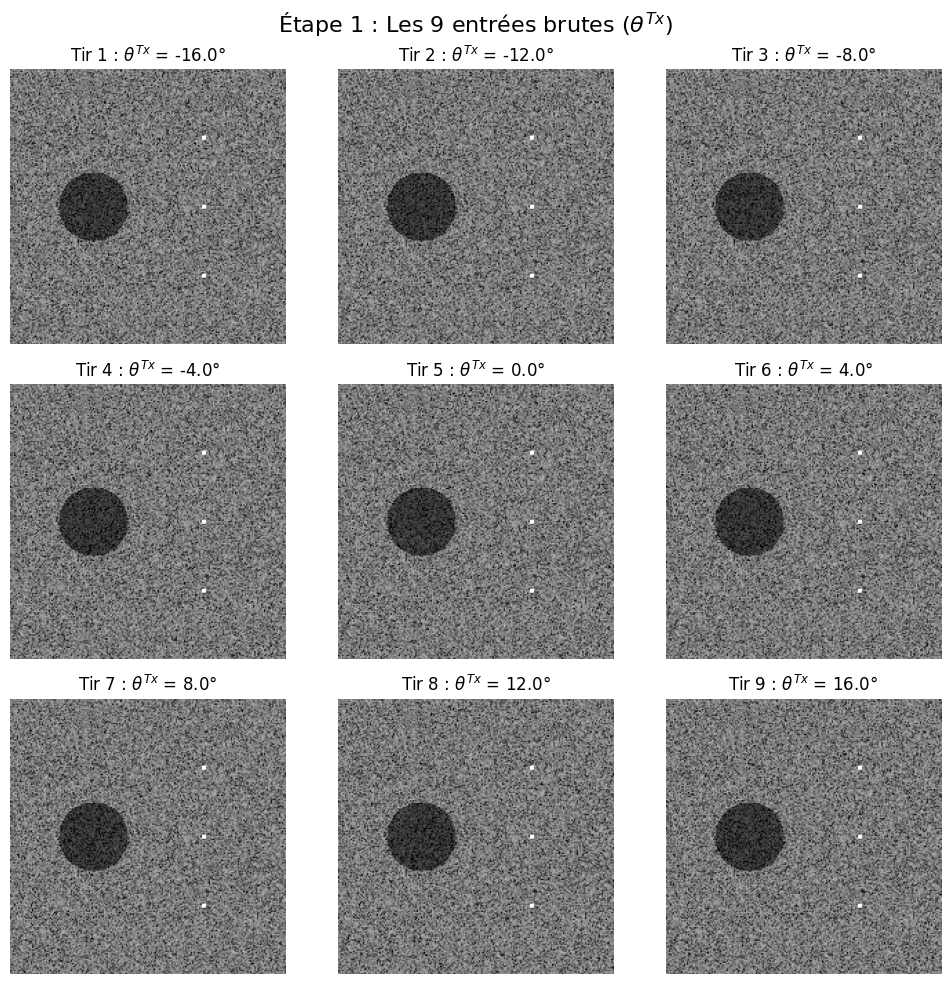

In [3]:
# Paramètres de simulation
n_tx = 9
nz, nx = 200, 200
f0 = 0.12
theta_tx = np.linspace(-16, 16, n_tx)

np.random.seed(42)
tissue = gaussian_filter(np.random.normal(0, 1.0, (nz, nx)), sigma=0.5)

cz, cx, r = 100, 60, 25
Z_mesh, X_mesh = np.ogrid[:nz, :nx]
tissue[(Z_mesh - cz)**2 + (X_mesh - cx)**2 <= r**2] *= 0.05

for pz, px in zip([50, 100, 150], [140, 140, 140]):
    tissue[pz-1:pz+2, px-1:px+2] = 15.0

carrier = np.exp(1j * 2 * np.pi * f0 * np.indices((nz, nx))[0])
phase_error = gaussian_filter(np.random.normal(0, 4.0, nx), sigma=6)

y_das_series = []
for angle in theta_tx:
    shift = int(30 * np.tan(np.deg2rad(angle)))
    aberration = np.exp(1j * 2 * np.pi * f0 * np.roll(phase_error, shift))
    noise = np.random.normal(0, 0.05, (nz, nx)) + 1j * np.random.normal(0, 0.05, (nz, nx))
    y_das_series.append(tissue * aberration * carrier + noise)

y_das_series = np.array(y_das_series)

# Affichage : grille des 9 acquisitions (B-mode)
fig, axes = plt.subplots(3, 3, figsize=(10, 10))
fig.suptitle("Étape 1 : Les 9 entrées brutes ($\\theta^{Tx}$)", fontsize=16)
for i in range(n_tx):
    ax = axes[i // 3, i % 3]
    b_mode = 20 * np.log10(np.abs(y_das_series[i]) + 1e-12)
    b_mode -= np.max(b_mode)
    ax.imshow(b_mode, cmap='gray', vmin=-60, vmax=0)
    ax.set_title(f"Tir {i+1} : $\\theta^{{Tx}}$ = {theta_tx[i]:.1f}°")
    ax.axis('off')
plt.tight_layout()
plt.subplots_adjust(top=0.92)
plt.show()


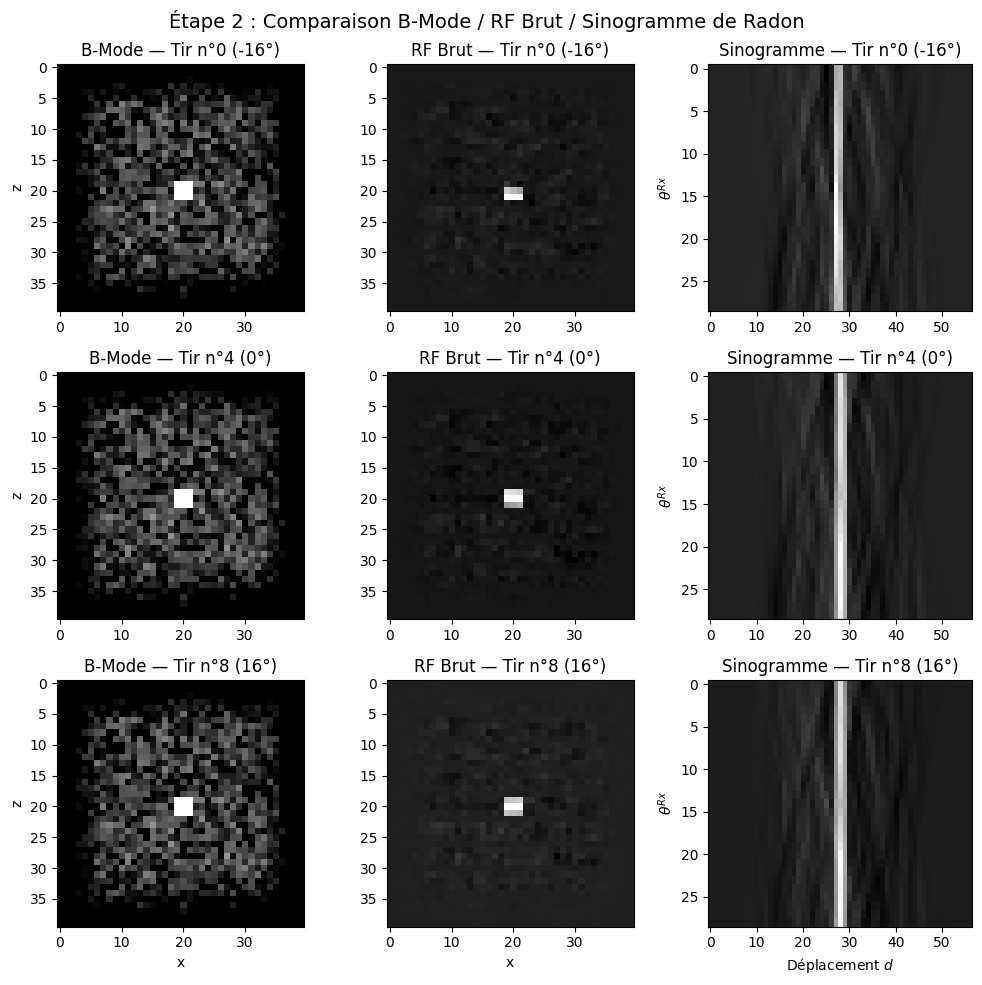

In [4]:
# Paramètres de fenêtrage et de réception
theta_rx = np.arange(-35, 35.1, 2.5)
angles_skimage = theta_rx + 90
n_rx = len(theta_rx)

win_size = 40
w_1d = tukey(win_size, alpha=0.5)
w_2d = np.outer(w_1d, w_1d)

z_patch, x_patch = 30, 120
patches = y_das_series[:, z_patch:z_patch+win_size, x_patch:x_patch+win_size] * w_2d

# Calcul B-mode, RF brut et sinogramme de Radon pour 3 tirs représentatifs
tirs = [(0, "-16°", patches[0]), (4, "0°", patches[4]), (8, "16°", patches[8])]
fig2, axes2 = plt.subplots(3, 3, figsize=(10, 10))
fig2.suptitle("Étape 2 : Comparaison B-Mode / RF Brut / Sinogramme de Radon", fontsize=14)

for row, (idx, label, patch) in enumerate(tirs):
    bmode = 20 * np.log10(np.abs(patch) + 1e-12)
    bmode -= np.max(bmode)
    patch_rf = np.real(patch)
    sinogram = radon(patch_rf, theta=angles_skimage, circle=False)

    axes2[row, 0].imshow(bmode, cmap='gray', vmin=-40, vmax=0)
    axes2[row, 0].set_title(f"B-Mode — Tir n°{idx} ({label})")
    axes2[row, 0].set_ylabel("z")

    axes2[row, 1].imshow(patch_rf, cmap='gray')
    axes2[row, 1].set_title(f"RF Brut — Tir n°{idx} ({label})")

    axes2[row, 2].imshow(sinogram.T, cmap='gray', aspect='auto')
    axes2[row, 2].set_title(f"Sinogramme — Tir n°{idx} ({label})")
    axes2[row, 2].set_ylabel("$\\theta^{Rx}$")

axes2[2, 0].set_xlabel("x")
axes2[2, 1].set_xlabel("x")
axes2[2, 2].set_xlabel("Déplacement $d$")
plt.tight_layout()
plt.show()


Tenseur S : (9, 29, 57)  (n_tx, n_rx, n_d)


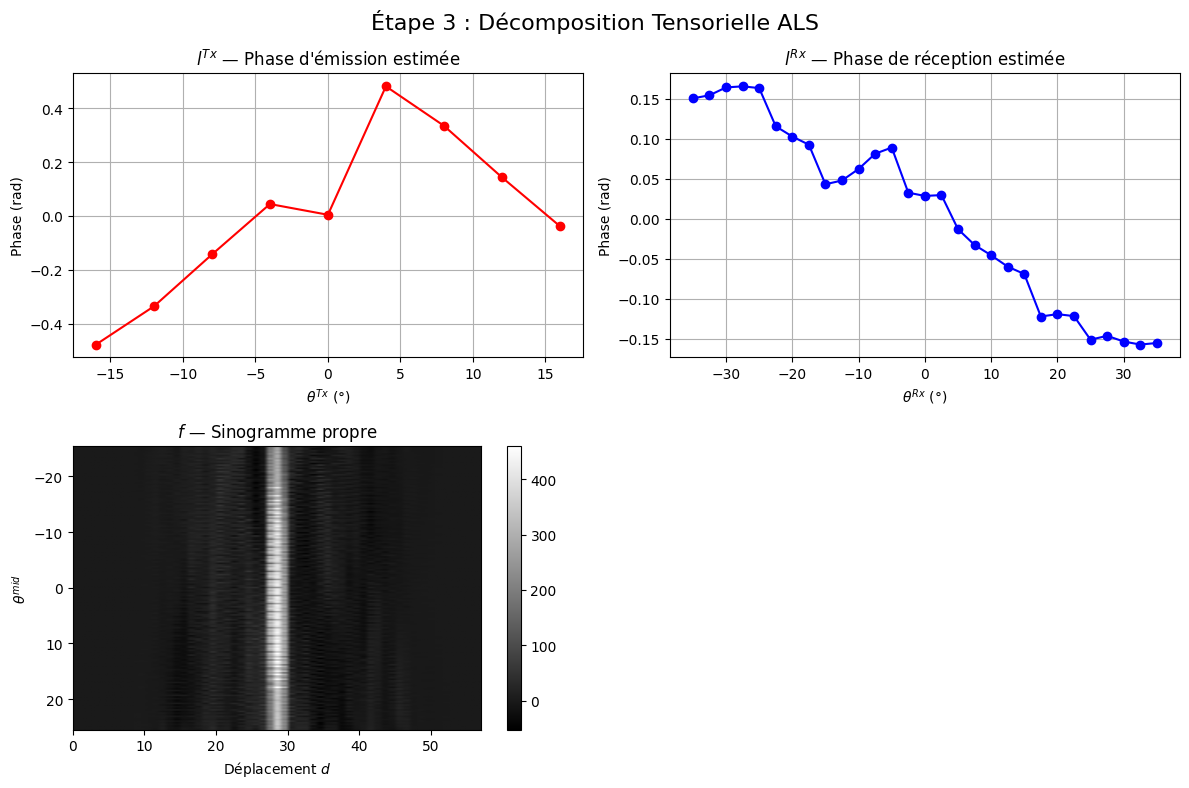

In [6]:
# Construction du tenseur 3D S(Tx, Rx, d)
s_patch = []
for i_tx in range(n_tx):
    s_real = radon(np.real(patches[i_tx]), theta=angles_skimage, circle=False)
    s_imag = radon(np.imag(patches[i_tx]), theta=angles_skimage, circle=False)
    s_patch.append(s_real + 1j * s_imag)
s_patch = np.array(s_patch).transpose((0, 2, 1))
n_d = s_patch.shape[2]

print(f"Tenseur S : {s_patch.shape}  (n_tx, n_rx, n_d)")

# Matrices géométriques : angle moyen θ_mid = (θ_tx + θ_rx) / 2
theta_tx_grid, theta_rx_grid = np.meshgrid(theta_tx, theta_rx, indexing='ij')
theta_mid_matrix = (theta_tx_grid + theta_rx_grid) / 2
theta_mid_unique, mid_idx_flat = np.unique(theta_mid_matrix, return_inverse=True)
mid_idx_matrix = mid_idx_flat.reshape(n_tx, n_rx)
n_mid = len(theta_mid_unique)

# ALS Rank-1 : initialisation
mu = 0.005
l_tx = np.ones(n_tx, dtype=np.complex128)
l_rx = np.ones(n_rx, dtype=np.complex128)
f_mid = np.zeros((n_mid, n_d), dtype=np.complex128)

for _ in range(8):
    norm_tx_sq = np.sum(np.abs(l_tx)**2)
    norm_rx_sq = np.sum(np.abs(l_rx)**2)

    # Mise à jour de f_mid
    num_f = np.zeros((n_mid, n_d), dtype=np.complex128)
    den_f = np.zeros(n_mid, dtype=np.float64)
    for i_tx in range(n_tx):
        for i_rx in range(n_rx):
            m = mid_idx_matrix[i_tx, i_rx]
            w = np.conj(l_tx[i_tx]) * np.conj(l_rx[i_rx])
            num_f[m] += w * s_patch[i_tx, i_rx]
            den_f[m] += np.abs(l_tx[i_tx] * l_rx[i_rx])**2
    f_mid = num_f / (den_f[:, None] + mu * norm_tx_sq * norm_rx_sq)
    norm_f_sq = np.sum(np.abs(f_mid)**2)

    # Mise à jour de l_rx
    num_rx = np.zeros(n_rx, dtype=np.complex128)
    den_rx = np.zeros(n_rx, dtype=np.float64)
    for i_tx in range(n_tx):
        for i_rx in range(n_rx):
            m = mid_idx_matrix[i_tx, i_rx]
            w = np.conj(l_tx[i_tx]) * np.conj(f_mid[m])
            num_rx[i_rx] += np.sum(w * s_patch[i_tx, i_rx])
            den_rx[i_rx] += np.abs(l_tx[i_tx])**2 * np.sum(np.abs(f_mid[m])**2)
    l_rx = num_rx / (den_rx + mu * norm_tx_sq * norm_f_sq)
    norm_rx_sq = np.sum(np.abs(l_rx)**2)

    # Mise à jour de l_tx
    num_tx = np.zeros(n_tx, dtype=np.complex128)
    den_tx = np.zeros(n_tx, dtype=np.float64)
    for i_tx in range(n_tx):
        for i_rx in range(n_rx):
            m = mid_idx_matrix[i_tx, i_rx]
            w = np.conj(l_rx[i_rx]) * np.conj(f_mid[m])
            num_tx[i_tx] += np.sum(w * s_patch[i_tx, i_rx])
            den_tx[i_tx] += np.abs(l_rx[i_rx])**2 * np.sum(np.abs(f_mid[m])**2)
    l_tx = num_tx / (den_tx + mu * norm_rx_sq * norm_f_sq)

    # Normalisation
    n_tx_norm = np.sqrt(np.sum(np.abs(l_tx)**2))
    n_rx_norm = np.sqrt(np.sum(np.abs(l_rx)**2))
    l_tx /= n_tx_norm
    l_rx /= n_rx_norm
    f_mid *= (n_tx_norm * n_rx_norm)

# Affichage des vecteurs de phase et du sinogramme propre
fig3, axes3 = plt.subplots(2, 2, figsize=(12, 8))
fig3.suptitle("Étape 3 : Décomposition Tensorielle ALS", fontsize=16)

axes3[0, 0].plot(theta_tx, np.angle(l_tx), 'ro-')
axes3[0, 0].set_title("$l^{Tx}$ — Phase d'émission estimée")
axes3[0, 0].set_xlabel("$\\theta^{Tx}$ (°)")
axes3[0, 0].set_ylabel("Phase (rad)")
axes3[0, 0].grid(True)

axes3[0, 1].plot(theta_rx, np.angle(l_rx), 'bo-')
axes3[0, 1].set_title("$l^{Rx}$ — Phase de réception estimée")
axes3[0, 1].set_xlabel("$\\theta^{Rx}$ (°)")
axes3[0, 1].set_ylabel("Phase (rad)")
axes3[0, 1].grid(True)

im3 = axes3[1, 0].imshow(
    np.real(f_mid), cmap='gray', aspect='auto',
    extent=[0, n_d, theta_mid_unique[-1], theta_mid_unique[0]]
)
axes3[1, 0].set_title("$f$ — Sinogramme propre")
axes3[1, 0].set_xlabel("Déplacement $d$")
axes3[1, 0].set_ylabel("$\\theta^{mid}$")
plt.colorbar(im3, ax=axes3[1, 0])

axes3[1, 1].axis('off')
plt.tight_layout()
plt.show()


In [7]:
step = 8
output_image_f = np.zeros((nz, nx), dtype=np.complex128)
norm_map = np.zeros((nz, nx), dtype=np.float64)
patches_dict = {}

z_steps = list(range(0, nz - win_size + 1, step))
if z_steps[-1] + win_size < nz: z_steps.append(nz - win_size)
x_steps = list(range(0, nx - win_size + 1, step))
if x_steps[-1] + win_size < nx: x_steps.append(nx - win_size)

total_patches = len(z_steps) * len(x_steps)
print(f"Lancement du pipeline sur {total_patches} patchs.")

patch_count = 0
for z in z_steps:
    for x in x_steps:
        patch_series = y_das_series[:, z:z+win_size, x:x+win_size] * w_2d
        
        # 1. Transformée de Radon
        s_patch_local = []
        for i_tx in range(n_tx):
            patch = patch_series[i_tx]
            s_real = radon(np.real(patch), theta=angles_skimage, circle=False)
            s_imag = radon(np.imag(patch), theta=angles_skimage, circle=False)
            s_patch_local.append(s_real + 1j * s_imag) 
        s_patch_local = np.array(s_patch_local).transpose((0, 2, 1))
        
        # 2. Tensor Rank-1 ALS
        l_tx_local, l_rx_local = np.ones(n_tx, dtype=np.complex128), np.ones(n_rx, dtype=np.complex128)
        f_mid_local = np.zeros((n_mid, n_d), dtype=np.complex128)
        
        for _ in range(5):
            norm_tx_sq, norm_rx_sq = np.sum(np.abs(l_tx_local)**2), np.sum(np.abs(l_rx_local)**2)
            
            num_f = np.zeros((n_mid, n_d), dtype=np.complex128)
            den_f = np.zeros(n_mid, dtype=np.float64)
            for i_tx in range(n_tx):
                for i_rx in range(n_rx):
                    m_idx = mid_idx_matrix[i_tx, i_rx]
                    weight = np.conj(l_tx_local[i_tx]) * np.conj(l_rx_local[i_rx])
                    num_f[m_idx, :] += weight * s_patch_local[i_tx, i_rx, :]
                    den_f[m_idx] += np.abs(l_tx_local[i_tx] * l_rx_local[i_rx])**2
            f_mid_local = num_f / (den_f[:, None] + mu * norm_tx_sq * norm_rx_sq)
            norm_f_sq = np.sum(np.abs(f_mid_local)**2)
            
            num_rx = np.zeros(n_rx, dtype=np.complex128)
            den_rx = np.zeros(n_rx, dtype=np.float64)
            for i_tx in range(n_tx):
                for i_rx in range(n_rx):
                    m_idx = mid_idx_matrix[i_tx, i_rx]
                    w_rx = np.conj(l_tx_local[i_tx]) * np.conj(f_mid_local[m_idx, :])
                    num_rx[i_rx] += np.sum(w_rx * s_patch_local[i_tx, i_rx, :])
                    den_rx[i_rx] += np.abs(l_tx_local[i_tx])**2 * np.sum(np.abs(f_mid_local[m_idx, :])**2)
            l_rx_local = num_rx / (den_rx + mu * norm_tx_sq * norm_f_sq)
            norm_rx_sq = np.sum(np.abs(l_rx_local)**2)
            
            num_tx = np.zeros(n_tx, dtype=np.complex128)
            den_tx = np.zeros(n_tx, dtype=np.float64)
            for i_tx in range(n_tx):
                for i_rx in range(n_rx):
                    m_idx = mid_idx_matrix[i_tx, i_rx]
                    w_tx = np.conj(l_rx_local[i_rx]) * np.conj(f_mid_local[m_idx, :])
                    num_tx[i_tx] += np.sum(w_tx * s_patch_local[i_tx, i_rx, :])
                    den_tx[i_tx] += np.abs(l_rx_local[i_rx])**2 * np.sum(np.abs(f_mid_local[m_idx, :])**2)
            l_tx_local = num_tx / (den_tx + mu * norm_rx_sq * norm_f_sq)

            n_tx_norm = np.sqrt(np.sum(np.abs(l_tx_local)**2))
            n_rx_norm = np.sqrt(np.sum(np.abs(l_rx_local)**2))
            l_tx_local /= n_tx_norm
            l_rx_local /= n_rx_norm
            f_mid_local *= (n_tx_norm * n_rx_norm)

        # 3. Phase Correction Spatiale (Au lieu du iradon pour éviter les artefacts)
        y_f_w = np.zeros((win_size, win_size), dtype=np.complex128)
        for i_tx in range(n_tx):
            y_f_w += patch_series[i_tx] * np.conj(l_tx_local[i_tx])
        y_f_w *= (1.0 / np.sqrt(n_tx))
        
        patches_dict[(z, x)] = y_f_w
        norm_map[z:z+win_size, x:x+win_size] += (w_2d ** 2)
        
        patch_count += 1
        if patch_count % 50 == 0:
            print(f"Progression : {patch_count} / {total_patches} patchs traités...")

print("Alignement des phases des patchs (Overlap-Add)...")
output_image_f.fill(0)

# Passe d'Initialisation Séquentielle 
for (z, x), y_f_w in patches_dict.items():
    y_f_0 = output_image_f[z:z+win_size, x:x+win_size]
    v = np.sum(y_f_0 * np.conj(y_f_w))
    if np.abs(v) > 1e-10:
        y_f_w = (v / np.abs(v)) * y_f_w 
    patches_dict[(z, x)] = y_f_w
    output_image_f[z:z+win_size, x:x+win_size] += y_f_w

# Affinage global 
for i_out in range(3):
    for (z, x), y_f_w in patches_dict.items():
        y_f_0 = output_image_f[z:z+win_size, x:x+win_size] - y_f_w
        v = np.sum(y_f_0 * np.conj(y_f_w))
        if np.abs(v) > 1e-10:
            patches_dict[(z, x)] = (v / np.abs(v)) * y_f_w
            
    output_image_f.fill(0)
    for (z, x), y_f_w in patches_dict.items():
        output_image_f[z:z+win_size, x:x+win_size] += y_f_w

mask = norm_map > 1e-5
output_image_f[mask] /= norm_map[mask]

Lancement du pipeline sur 441 patchs.
Progression : 50 / 441 patchs traités...
Progression : 100 / 441 patchs traités...
Progression : 150 / 441 patchs traités...
Progression : 200 / 441 patchs traités...
Progression : 250 / 441 patchs traités...
Progression : 300 / 441 patchs traités...
Progression : 350 / 441 patchs traités...
Progression : 400 / 441 patchs traités...
Alignement des phases des patchs (Overlap-Add)...


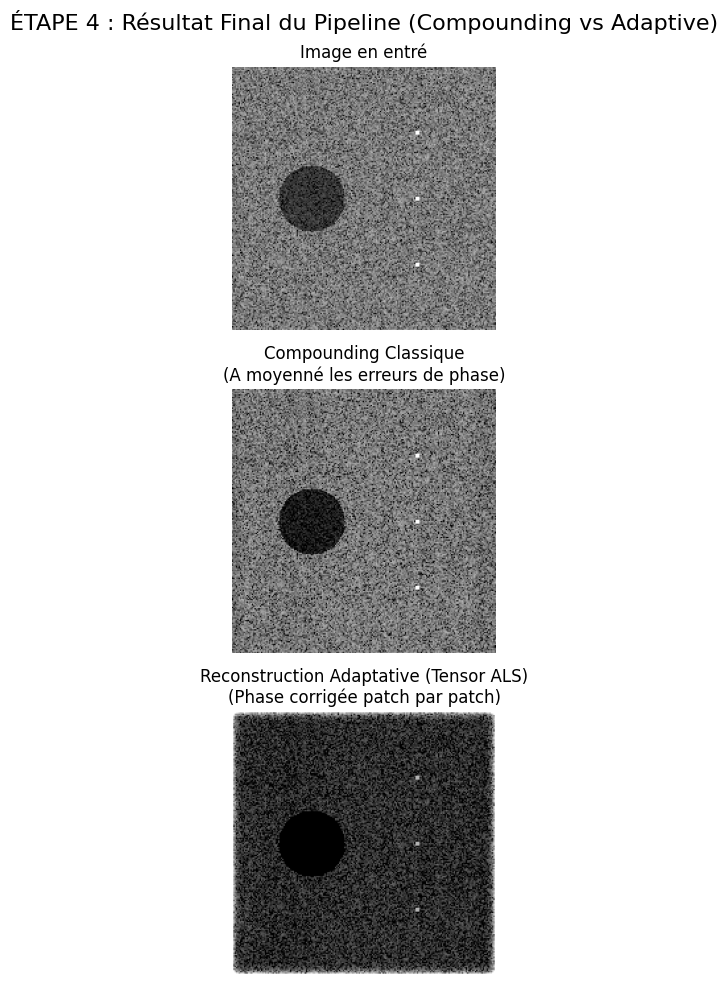

In [20]:
b_mode_in = 20 * np.log10(np.abs(y_das_series[4])+ 1e-12)
b_mode_in-=np.max(b_mode_in)

base_compounding = np.mean(y_das_series, axis=0)
base_b_mode = 20 * np.log10(np.abs(base_compounding) + 1e-12)
base_b_mode -= np.max(base_b_mode)

b_mode = np.zeros((nz, nx))
b_mode_temp = 20 * np.log10(np.abs(output_image_f) + 1e-12)
b_mode[mask] = b_mode_temp[mask] - np.max(b_mode_temp[mask])

fig4, axes4 = plt.subplots(3, 1, figsize=(12, 10))
fig4.suptitle("ÉTAPE 4 : Résultat Final du Pipeline (Compounding vs Adaptive)", fontsize=16)

axes4[0].imshow(b_mode_in, cmap='gray', vmin=-60, vmax=0)
axes4[0].set_title("Image en entré")

axes4[1].imshow(base_b_mode, cmap='gray', vmin=-60, vmax=0)
axes4[1].set_title("Compounding Classique\n(A moyenné les erreurs de phase)")

axes4[2].imshow(b_mode, cmap='gray', vmin=-60, vmax=0)
axes4[2].set_title("Reconstruction Adaptative (Tensor ALS)\n(Phase corrigée patch par patch)")
for ax in axes4: ax.axis('off')
plt.tight_layout()
plt.show()